In [3]:
import torch
from torch.utils.data import Dataset
import torchaudio
from IPython.display import Audio, display
import librosa
from torch import nn
from torch.utils.data import DataLoader
import os
import matplotlib.pyplot as plt
import numpy as np
import glob
import torch.nn.functional as F
from numpy import random

In [4]:
#读取训练文件
filelist=[] # to store noisy audio
labellist=[] # to store clean audio 

noisypath="./data/noizeus/withnoise/"
cleanpath='./data/noizeus/clean/'

noiseyfolders=os.listdir(noisypath)
cleanfolders=os.listdir(cleanpath)

for folder in noiseyfolders:
    audios=os.listdir(noisypath+folder+"/")
    for audio in audios:
        filelist.append(noisypath+folder+"/"+audio)
        
for audio in cleanfolders:
    labellist.append(cleanpath+audio)

print('read {} noisy files.'.format(len(filelist)))
print('read {} clean files.'.format(len(labellist)))

read 450 noisy files.
read 30 clean files.


In [5]:
def spectrogram(wav):
    win_length=256
    n_fft=256
    hop_length=64
    wav = wav.squeeze()
    S = torch.stft(wav, n_fft=n_fft, hop_length=hop_length,
                   win_length=win_length, window=torch.hann_window(window_length=win_length),
                   center=True, return_complex=True)   
    magnitude = torch.abs(S)        # 振幅
    phase = torch.exp(1j * torch.angle(S))  # 相位
    return magnitude, phase

In [6]:
#构建pytorch数据集
class mydataset(Dataset):
    def __init__(self,filelist,labellist):
        self.filelist=filelist
        self.labellist=labellist
        self.win_length=256
        self.hop_length=64
        self.n_fft=256
        
    def __len__(self):
        return len(self.filelist*2)

    def __getitem__(self, idx):
        f=idx//2
        n=idx%2
        
        noised_waveform,_= torchaudio.load(self.filelist[f])
        noised_waveform = noised_waveform[0][:16704]#[16704,]
        noised_waveform=noised_waveform.unsqueeze(0)#[1,16704]
        
        clean_waveform,_=torchaudio.load(self.labellist[int(filelist[f][-6:-4])-1])
        clean_waveform = clean_waveform[0][:16704]#[16704,]
        clean_waveform=clean_waveform.unsqueeze(0)#[1,16704]
        
        noise_waveform=noised_waveform-clean_waveform
        
        noised_mag ,_ = spectrogram(noised_waveform)
        clean_mag ,_ = spectrogram(clean_waveform)
        noise_mag,_ = spectrogram(noise_waveform)
        
        #语谱图shape[129, 258],截成两张[129,129]
        postion=n
        length=129
        sliced_noised=noised_mag[:,length*postion:length*(postion+1)]
        sliced_clean=clean_mag[:,length*(postion):length*(postion+1)]
        sliced_noise=noise_mag[:,length*(postion):length*(postion+1)]
        #single_frame_noised_mag= sliced_noised[:,length:2*length]
        
        _eps = torch.finfo(torch.float).eps  # 防止分母出现0
        mask_IRM = torch.sqrt(sliced_clean ** 2/(sliced_noise ** 2+sliced_clean ** 2+_eps))  # IRM，模型输出
        label=mask_IRM #掩蔽
        return sliced_noised.unsqueeze(0),label.unsqueeze(0)

In [7]:
#实例化MyDataset类
dataset=mydataset(filelist,labellist)
#查看dataset值
print(dataset[2][0].shape)
print(dataset[2][1].shape)

torch.Size([1, 129, 129])
torch.Size([1, 129, 129])


In [8]:
#按照0.8 0.2比例分割训练集和验证集
length=len(dataset)
train_size = int(0.8 * len(dataset))
validate_size = len(dataset) - train_size
train_set,validate_set=torch.utils.data.random_split(dataset,[train_size,validate_size])
batch_size=16
train_dataloader = DataLoader(train_set, batch_size=batch_size,shuffle=True)
validate_dataloader = DataLoader(validate_set, batch_size=batch_size,shuffle=True)

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [10]:
#8层GRU 输入格式要求[batch channel sequence feature]
class RNN(nn.Module):
    def __init__(self):
        super(RNN, self).__init__()
        self.gru1=nn.GRU(129,hidden_size=1024,num_layers=1,batch_first=True)
        self.gru2=nn.GRU(1024,hidden_size=1024,num_layers=6,batch_first=True)
        self.gru3=nn.GRU(1024,hidden_size=129,num_layers=1,batch_first=True)
        self.sig=nn.Sigmoid()
         
    def forward(self, x):
        n_channels, n_f_bins, n_frame_size = x.shape[-3],x.shape[-2],x.shape[-1]
        gru_in = x.reshape(-1, n_channels * n_f_bins, n_frame_size).transpose(-1,-2)
        gru_out,_ = self.gru1(gru_in)
        gru_out,_ = self.gru2(gru_out)
        gru_out,_ = self.gru3(gru_out)
        gru_out = gru_out.transpose(-1,-2).reshape(-1, n_channels, n_f_bins, n_frame_size)
        out=self.sig(gru_out)
        return out

model = RNN().to(device)


In [11]:
#查看输出shape
x=torch.rand([16,1,129,129]).to(device) 
print(model)
print(model(x).shape)

RNN(
  (gru1): GRU(129, 1024, batch_first=True)
  (gru2): GRU(1024, 1024, num_layers=6, batch_first=True)
  (gru3): GRU(1024, 129, batch_first=True)
  (sig): Sigmoid()
)
torch.Size([16, 1, 129, 129])


In [26]:
loss_fn = nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4,)

In [27]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 计算损失函数
        pred = model(X)
        loss = loss_fn(pred, y)

        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 10 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [13]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
    test_loss /= num_batches
    print(f"Test Error: \n Avg loss: {test_loss:>8f} \n")

In [28]:
# 如果需要加载已有模型参数，取消注释
# model.load_state_dict(torch.load('./model/rnn_gru.pt',map_location=device))

epochs = 3
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(validate_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 0.075904  [    0/  720]
loss: 0.082758  [  160/  720]
loss: 0.074048  [  320/  720]
loss: 0.074888  [  480/  720]
loss: 0.075323  [  640/  720]
Test Error: 
 Avg loss: 0.076179 

Epoch 2
-------------------------------
loss: 0.075332  [    0/  720]
loss: 0.078838  [  160/  720]
loss: 0.076073  [  320/  720]
loss: 0.073859  [  480/  720]
loss: 0.073655  [  640/  720]
Test Error: 
 Avg loss: 0.075070 

Epoch 3
-------------------------------
loss: 0.072073  [    0/  720]
loss: 0.072466  [  160/  720]
loss: 0.074202  [  320/  720]
loss: 0.072508  [  480/  720]
loss: 0.073072  [  640/  720]
Test Error: 
 Avg loss: 0.073575 

Done!


In [29]:
# Save the model
if not os.path.exists('./model'):
    os.makedirs('./model')
torch.save(model.state_dict(),"./model/rnn_gru.pt")

In [30]:
def plot_spectrogram(spec, title=None, ylabel='freq_bin', aspect='auto', xmax=None,
                     if_log=True):
    fig, axs = plt.subplots(1, 1)
    axs.set_title(title or 'Spectrogram (db)')
    axs.set_ylabel(ylabel)
    axs.set_xlabel('frame')
    if if_log:
        spec = librosa.power_to_db(spec,ref=np.max)
    im = axs.imshow(spec, origin='lower', aspect=aspect,cmap='jet')
    if xmax:
        axs.set_xlim((0, xmax))
    fig.colorbar(im, ax=axs)
    plt.show(block=False)

torch.Size([1, 129, 129])


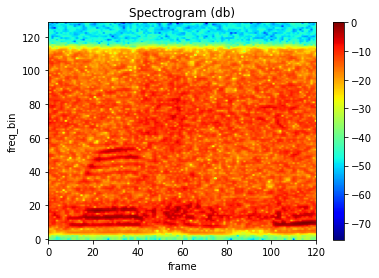

In [38]:
s=validate_set[0][0]
print(s.shape)
plot_spectrogram(s[0],xmax=120)#带噪语谱图

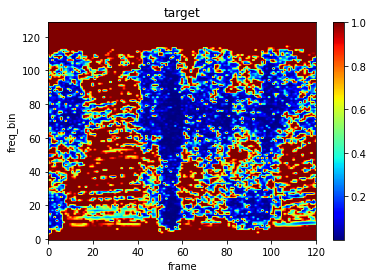

In [39]:
c=validate_set[0][1][0]/validate_set[0][0][0]
c[c>1]=1
plot_spectrogram(c,if_log=False,title='target',xmax=120) #target

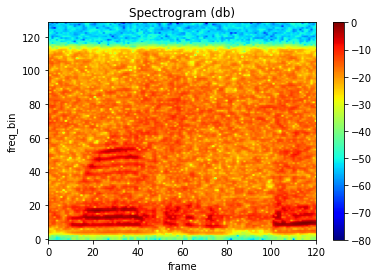

In [40]:
irm=model(s.to(device).unsqueeze(0))
denoised=irm*s.to(device)
plot_spectrogram(denoised[0][0].detach().cpu(),xmax=120)#降噪后语谱图

In [45]:
# 测试环节
model = RNN().to(device)
model.load_state_dict(torch.load('./model/rnn_gru.pt',map_location=device))

<All keys matched successfully>

In [47]:
#从测试音频中挑选一个进行降噪
num=3 #可以为1，2，3
noised_waveform,_= torchaudio.load('./data/mynoise{}.wav'.format(num))
noised_waveform=noised_waveform[:,:16704]
mag,phase=spectrogram(noised_waveform)
phase = phase.to(device)
mag1=mag[:,:129].to(device)
denoised_mag1=mag1*model(mag1.unsqueeze(0).unsqueeze(0))[0]
mag2=mag[:,129:].to(device)
denoised_mag2=mag2*model(mag2.unsqueeze(0).unsqueeze(0))[0]
denoised_mag=torch.cat([denoised_mag1,denoised_mag2],dim=2)
complex_stft = (denoised_mag * phase).detach().cpu()
waveform=torch.istft(complex_stft, n_fft=256, hop_length=64, win_length=256,
                          window=torch.hann_window(window_length=256),center=True)

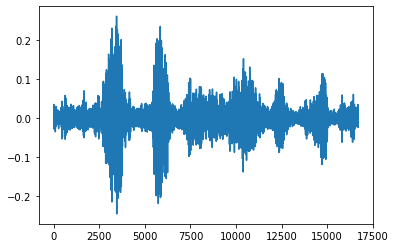

In [48]:
plt.plot(waveform.squeeze().numpy())#降噪后波形

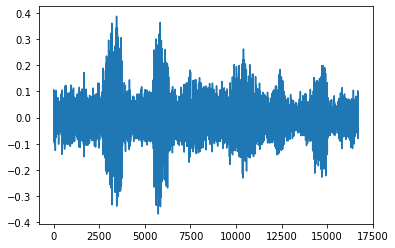

In [49]:
plt.plot(noised_waveform.squeeze().numpy())#降噪前波形

In [31]:
# 绘制降噪后语音的语谱图


In [32]:
# 绘制原始含噪语音的语谱图


In [58]:
#播放试听
def play_audio(waveform, sample_rate):
    waveform = waveform.numpy()

    num_channels, num_frames = waveform.shape
    if num_channels == 1:
        display(Audio(waveform[0], rate=sample_rate))
    elif num_channels == 2:
        display(Audio((waveform[0], waveform[1]), rate=sample_rate))
    else:
        raise ValueError("Waveform with more than 2 channels are not supported.")

In [59]:
play_audio(noised_waveform,8000)

In [60]:
play_audio(waveform,8000)